<a href="https://colab.research.google.com/github/vaibhavjiyer87/engine-nvh-deep-learning/blob/main/notebooks/06_baseline_feature_generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 1 — Mount Google Drive

# ============================================================
# CELL 1 — MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

# Persistent project location in Google Drive
PROJECT_DRIVE = Path(
    "/content/drive/MyDrive/"
    "NVH_DeepLearning/01_EngineOperatingState"
)

if not PROJECT_DRIVE.exists():
    raise FileNotFoundError(
        f"Project folder was not found:\n{PROJECT_DRIVE}"
    )

print("Google Drive mounted successfully.")
print(f"Project Drive: {PROJECT_DRIVE}")

Mounted at /content/drive
Google Drive mounted successfully.
Project Drive: /content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState


In [2]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 2 — Authenticate GitHub + determine Git author identity
# This assumes your GitHub token is stored in Colab Secrets under:
# GITHUB_TOKEN

# ============================================================
# CELL 2 — AUTHENTICATE GITHUB
# ============================================================

from google.colab import userdata

import os
import shutil
import subprocess


# ------------------------------------------------------------
# Repository settings
# ------------------------------------------------------------

REPOSITORY_NAME = "engine-nvh-deep-learning"


# ------------------------------------------------------------
# Load GitHub token securely from Colab Secrets
# ------------------------------------------------------------

github_token = userdata.get("GITHUB_TOKEN")

if not github_token:
    raise ValueError(
        "GITHUB_TOKEN was not found in Colab Secrets.\n"
        "Add the token and enable Notebook access."
    )

# GitHub CLI recognizes GH_TOKEN automatically.
os.environ["GH_TOKEN"] = github_token
os.environ["GH_HOST"] = "github.com"


# ------------------------------------------------------------
# Install GitHub CLI if necessary
# ------------------------------------------------------------

if shutil.which("gh") is None:

    print("Installing GitHub CLI...")

    subprocess.run(
        ["apt-get", "update", "-qq"],
        check=True,
    )

    subprocess.run(
        [
            "apt-get",
            "install",
            "-y",
            "-qq",
            "gh",
        ],
        check=True,
    )


# ------------------------------------------------------------
# Verify authentication
# ------------------------------------------------------------

auth_result = subprocess.run(
    [
        "gh",
        "api",
        "user",
        "--jq",
        ".login",
    ],
    capture_output=True,
    text=True,
)

if auth_result.returncode != 0:

    print(auth_result.stderr)

    raise RuntimeError(
        "GitHub authentication failed."
    )


GITHUB_USERNAME = auth_result.stdout.strip()

# ------------------------------------------------------------
# Configure Git commit identity
# ------------------------------------------------------------

user_id_result = subprocess.run(
    [
        "gh",
        "api",
        "user",
        "--jq",
        ".id",
    ],
    capture_output=True,
    text=True,
    check=True,
)

GITHUB_USER_ID = (
    user_id_result.stdout.strip()
)

GIT_NAME = GITHUB_USERNAME

GIT_EMAIL = (
    f"{GITHUB_USER_ID}+"
    f"{GITHUB_USERNAME}@users.noreply.github.com"
)

print("Git identity prepared.")
print(f"Name:  {GIT_NAME}")
print(f"Email: {GIT_EMAIL}")

# ------------------------------------------------------------
# Configure Git to use GitHub CLI authentication
# ------------------------------------------------------------

subprocess.run(
    [
        "gh",
        "auth",
        "setup-git",
        "--hostname",
        "github.com",
        "--force",
    ],
    check=True,
)


print("GitHub authentication successful.")
print(f"GitHub user: {GITHUB_USERNAME}")
print(f"Repository:  {REPOSITORY_NAME}")

Git identity prepared.
Name:  vaibhavjiyer87
Email: 312107027+vaibhavjiyer87@users.noreply.github.com
GitHub authentication successful.
GitHub user: vaibhavjiyer87
Repository:  engine-nvh-deep-learning


In [3]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 3 — Clone repository if .git is missing / Update repository
# This cell deals with the temporary nature of /content.

# ============================================================
# CELL 3 — RESTORE LOCAL GITHUB REPOSITORY
# ============================================================

from pathlib import Path
import shutil
import subprocess


TEMP_REPO_DIR = (
    Path("/content")
    / REPOSITORY_NAME
)

REPOSITORY_IDENTIFIER = (
    f"{GITHUB_USERNAME}/"
    f"{REPOSITORY_NAME}"
)


# ------------------------------------------------------------
# Case 1:
# Valid Git repository already exists
# ------------------------------------------------------------

if (
    TEMP_REPO_DIR.exists()
    and
    (TEMP_REPO_DIR / ".git").exists()
):

    print(
        "Git repository already exists "
        "in this Colab runtime."
    )

    # Pull updates only when the working tree is clean.
    status_result = subprocess.run(
        [
            "git",
            "-C",
            str(TEMP_REPO_DIR),
            "status",
            "--porcelain",
        ],
        capture_output=True,
        text=True,
        check=True,
    )

    if status_result.stdout.strip():

        print(
            "Local changes detected."
        )

        print(
            "Automatic git pull skipped "
            "to avoid overwriting local work."
        )

    else:

        print(
            "Working tree is clean. "
            "Updating from GitHub..."
        )

        pull_result = subprocess.run(
            [
                "git",
                "-C",
                str(TEMP_REPO_DIR),
                "pull",
                "--ff-only",
            ],
            capture_output=True,
            text=True,
        )

        print(pull_result.stdout)

        if pull_result.returncode != 0:
            print(pull_result.stderr)


# ------------------------------------------------------------
# Case 2:
# Folder exists, but it is NOT a Git repository
# ------------------------------------------------------------

elif TEMP_REPO_DIR.exists():

    raise RuntimeError(
        f"The folder exists but is not a Git repository:\n"
        f"{TEMP_REPO_DIR}\n\n"
        "Do not run git init. Inspect or back up the folder "
        "before removing it and rerunning this cell."
    )


# ------------------------------------------------------------
# Case 3:
# Fresh runtime — clone repository
# ------------------------------------------------------------

else:

    print(
        "Repository not present in this runtime."
    )

    print(
        f"Cloning {REPOSITORY_IDENTIFIER}..."
    )

    clone_result = subprocess.run(
        [
            "gh",
            "repo",
            "clone",
            REPOSITORY_IDENTIFIER,
            str(TEMP_REPO_DIR),
        ],
        capture_output=True,
        text=True,
    )

    print(clone_result.stdout)

    if clone_result.returncode != 0:

        print(clone_result.stderr)

        raise RuntimeError(
            "Repository clone failed."
        )


# ------------------------------------------------------------
# Final verification
# ------------------------------------------------------------

if not (
    TEMP_REPO_DIR
    / ".git"
).exists():

    raise RuntimeError(
        "Repository restoration failed."
    )


print("Local Git repository is ready.")
print(f"Location: {TEMP_REPO_DIR}")

Repository not present in this runtime.
Cloning vaibhavjiyer87/engine-nvh-deep-learning...

Local Git repository is ready.
Location: /content/engine-nvh-deep-learning


In [4]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 4 — Define REPO_DIR and all standard paths + restore requirements

# ============================================================
# CELL 4 — DEFINE PROJECT PATHS
# ============================================================

from pathlib import Path


# ------------------------------------------------------------
# GitHub working repository
# ------------------------------------------------------------

REPO_DIR = (
    Path("/content")
    / REPOSITORY_NAME
)

if not (
    REPO_DIR
    / ".git"
).exists():

    raise FileNotFoundError(
        f"Valid Git repository not found at:\n"
        f"{REPO_DIR}\n\n"
        "Run Cell 3 first."
    )


# ------------------------------------------------------------
# Persistent raw dataset
# ------------------------------------------------------------

RAW_ROOT = (
    PROJECT_DRIVE
    / "data"
    / "raw"
    / "procedural_engine_sounds"
)

DATASET_ROOT = (
    RAW_ROOT
    / "dataset"
)

AUDIO_DIR = (
    DATASET_ROOT
    / "audio"
    / "A_full_set"
)


# ------------------------------------------------------------
# Persistent Google Drive manifests
# ------------------------------------------------------------

DRIVE_MANIFEST_DIR = (
    PROJECT_DRIVE
    / "data"
    / "manifests"
)


# ------------------------------------------------------------
# GitHub configuration
# ------------------------------------------------------------

CONFIG_DIR = (
    REPO_DIR
    / "configs"
)

REPORT_DIR = (
    REPO_DIR
    / "reports"
)

SPLIT_DIR = (
    REPO_DIR
    / "data"
    / "splits"
)


# ------------------------------------------------------------
# GitHub result directories
# ------------------------------------------------------------

RESULTS_DIR = (
    REPO_DIR
    / "results"
)

FIGURE_DIR = (
    RESULTS_DIR
    / "figures"
)

TABLE_DIR = (
    RESULTS_DIR
    / "tables"
)

DATA_AUDIT_FIGURE_DIR = (
    FIGURE_DIR
    / "data_audit"
)

DESIGN_FIGURE_DIR = (
    FIGURE_DIR
    / "preprocessing_design"
)

SPLIT_FIGURE_DIR = (
    FIGURE_DIR
    / "split_design"
)


# ------------------------------------------------------------
# Persistent Drive output directories
# ------------------------------------------------------------

DRIVE_OUTPUT_DIR = (
    PROJECT_DRIVE
    / "outputs"
)

DRIVE_DESIGN_TABLE_DIR = (
    DRIVE_OUTPUT_DIR
    / "tables"
    / "preprocessing_design"
)


# ------------------------------------------------------------
# Create output folders if missing
# ------------------------------------------------------------

directories_to_create = [
    CONFIG_DIR,
    REPORT_DIR,
    SPLIT_DIR,
    FIGURE_DIR,
    TABLE_DIR,
    DATA_AUDIT_FIGURE_DIR,
    DESIGN_FIGURE_DIR,
    SPLIT_FIGURE_DIR,
    DRIVE_DESIGN_TABLE_DIR,
]

for directory in directories_to_create:

    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


print("Project paths restored.")
print()
print(f"REPO_DIR:     {REPO_DIR}")
print(f"PROJECT_DRIVE:{PROJECT_DRIVE}")
print(f"RAW_ROOT:     {RAW_ROOT}")
print(f"AUDIO_DIR:    {AUDIO_DIR}")

# ------------------------------------------------------------
# Apply Git commit identity to cloned repository
# ------------------------------------------------------------

subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "config",
        "user.name",
        GIT_NAME,
    ],
    check=True,
)

subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "config",
        "user.email",
        GIT_EMAIL,
    ],
    check=True,
)

print("Git commit identity applied to repository.")

# ------------------------------------------------------------
# Restore project Python dependencies
# ------------------------------------------------------------

import subprocess

REQUIREMENTS_PATH = (
    REPO_DIR
    / "requirements.txt"
)

if not REQUIREMENTS_PATH.exists():
    raise FileNotFoundError(
        f"requirements.txt not found:\n"
        f"{REQUIREMENTS_PATH}"
    )

install_result = subprocess.run(
    [
        "python",
        "-m",
        "pip",
        "install",
        "-q",
        "-r",
        str(REQUIREMENTS_PATH),
    ],
    capture_output=True,
    text=True,
)

if install_result.returncode != 0:

    print(install_result.stdout)
    print(install_result.stderr)

    raise RuntimeError(
        "Project dependency installation failed."
    )

print(
    "Project Python dependencies restored."
)

Project paths restored.

REPO_DIR:     /content/engine-nvh-deep-learning
PROJECT_DRIVE:/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState
RAW_ROOT:     /content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/data/raw/procedural_engine_sounds
AUDIO_DIR:    /content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/data/raw/procedural_engine_sounds/dataset/audio/A_full_set
Git commit identity applied to repository.
Project Python dependencies restored.


In [5]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 5 — Load persistent analysis data
# This cell restores the major tables you've created so far.
# This is conditional, as some files may not exist yet depending on
# where you are in the project.

# ============================================================
# CELL 5 — LOAD PERSISTENT ANALYSIS DATA
# ============================================================

# ============================================================
# STANDARD PROJECT IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import yaml

from tqdm.auto import tqdm

print(
    "Standard project libraries imported."
)


# ------------------------------------------------------------
# 1. Raw-file manifest — REQUIRED
# ------------------------------------------------------------

RAW_MANIFEST_PATH = (
    DRIVE_MANIFEST_DIR
    / "raw_file_manifest_v001.csv"
)

if not RAW_MANIFEST_PATH.exists():

    raise FileNotFoundError(
        f"Required raw manifest not found:\n"
        f"{RAW_MANIFEST_PATH}"
    )


raw_manifest = pd.read_csv(
    RAW_MANIFEST_PATH
)

print(
    f"LOADED raw_manifest: "
    f"{raw_manifest.shape}"
)


# ------------------------------------------------------------
# 2. PREP-001 detailed target analysis — OPTIONAL
# ------------------------------------------------------------

PREP001_TARGET_PATH = (
    DRIVE_DESIGN_TABLE_DIR
    / "prep001_target_analysis_v001.csv.gz"
)

if PREP001_TARGET_PATH.exists():

    prep001_targets = pd.read_csv(
        PREP001_TARGET_PATH
    )

    print(
        f"LOADED prep001_targets: "
        f"{prep001_targets.shape}"
    )

else:

    prep001_targets = None

    print(
        "NOT FOUND: prep001 target analysis "
        "(this is okay if it has not been generated yet)."
    )


# ------------------------------------------------------------
# 3. Window candidate metrics — OPTIONAL
# ------------------------------------------------------------

WINDOW_CANDIDATE_PATH = (
    DRIVE_DESIGN_TABLE_DIR
    / "window_candidate_metrics_v001.csv.gz"
)

if WINDOW_CANDIDATE_PATH.exists():

    window_candidates = pd.read_csv(
        WINDOW_CANDIDATE_PATH
    )

    print(
        f"LOADED window_candidates: "
        f"{window_candidates.shape}"
    )

else:

    window_candidates = None

    print(
        "NOT FOUND: window candidate metrics."
    )


# ------------------------------------------------------------
# 4. Frozen SPLIT-001 file assignment — OPTIONAL
# ------------------------------------------------------------

FILE_SPLIT_PATH = (
    SPLIT_DIR
    / "file_split_v001.csv"
)

if FILE_SPLIT_PATH.exists():

    file_split = pd.read_csv(
        FILE_SPLIT_PATH
    )

    print(
        f"LOADED file_split: "
        f"{file_split.shape}"
    )

else:

    file_split = None

    print(
        "NOT FOUND: SPLIT-001 file assignment."
    )


# ============================================================
# LOAD REQUIRED FROZEN PROJECT SPECIFICATIONS
# ============================================================

import yaml


# ------------------------------------------------------------
# PREP-001 — REQUIRED
# ------------------------------------------------------------

PREPROCESSING_CONFIG_PATH = (
    CONFIG_DIR
    / "preprocessing_v001.yaml"
)

if not PREPROCESSING_CONFIG_PATH.exists():

    raise FileNotFoundError(
        "Required PREP-001 configuration is missing:\n"
        f"{PREPROCESSING_CONFIG_PATH}"
    )


try:

    with open(
        PREPROCESSING_CONFIG_PATH,
        "r",
        encoding="utf-8",
    ) as file:

        preprocessing_config = (
            yaml.safe_load(file)
        )

except yaml.YAMLError as error:

    raise RuntimeError(
        "PREP-001 exists but is invalid YAML.\n"
        f"{error}"
    )


if (
    preprocessing_config[
        "specification"
    ]["preprocessing_version"]
    != "PREP-001"
):

    raise RuntimeError(
        "Unexpected preprocessing version."
    )


print(
    "LOADED preprocessing_config: PREP-001"
)


# ------------------------------------------------------------
# SPLIT-001 — REQUIRED
# ------------------------------------------------------------

SPLIT_CONFIG_PATH = (
    CONFIG_DIR
    / "split_v001.yaml"
)

if not SPLIT_CONFIG_PATH.exists():

    raise FileNotFoundError(
        "Required SPLIT-001 configuration is missing:\n"
        f"{SPLIT_CONFIG_PATH}"
    )


try:

    with open(
        SPLIT_CONFIG_PATH,
        "r",
        encoding="utf-8",
    ) as file:

        split_config = (
            yaml.safe_load(file)
        )

except yaml.YAMLError as error:

    raise RuntimeError(
        "SPLIT-001 exists but is invalid YAML.\n"
        f"{error}"
    )


if (
    split_config[
        "specification"
    ]["split_version"]
    != "SPLIT-001"
):

    raise RuntimeError(
        "Unexpected split version."
    )


print(
    "LOADED split_config: SPLIT-001"
)


# ------------------------------------------------------------
# FILE SPLIT — REQUIRED
# ------------------------------------------------------------

FILE_SPLIT_PATH = (
    SPLIT_DIR
    / "file_split_v001.csv"
)

if not FILE_SPLIT_PATH.exists():

    raise FileNotFoundError(
        "Required SPLIT-001 assignment file is missing:\n"
        f"{FILE_SPLIT_PATH}"
    )


file_split = pd.read_csv(
    FILE_SPLIT_PATH
)

print(
    f"LOADED file_split: "
    f"{file_split.shape}"
)


# ============================================================
# DERIVE FROZEN RUNTIME CONSTANTS
# ============================================================

# ------------------------------------------------------------
# PREP-001 identity
# ------------------------------------------------------------

PREPROCESSING_VERSION = (
    preprocessing_config[
        "specification"
    ]["preprocessing_version"]
)

DATASET_SUBSET = (
    preprocessing_config[
        "specification"
    ]["dataset_subset"]
)


# ------------------------------------------------------------
# Windowing
# ------------------------------------------------------------

WINDOW_DURATION_S = float(
    preprocessing_config[
        "windowing"
    ]["window_duration_s"]
)

OVERLAP_FRACTION = float(
    preprocessing_config[
        "windowing"
    ]["overlap_fraction"]
)

HOP_DURATION_S = float(
    preprocessing_config[
        "windowing"
    ]["hop_duration_s"]
)


# ------------------------------------------------------------
# Source-data definition
# ------------------------------------------------------------

SOURCE_SAMPLE_RATE_HZ = int(
    preprocessing_config[
        "source_data"
    ]["source_sample_rate_hz"]
)

EXPECTED_CHANNELS = int(
    preprocessing_config[
        "source_data"
    ]["expected_channels"]
)

RPM_SCALE_FACTOR = float(
    preprocessing_config[
        "source_data"
    ]["rpm_scale_factor"]
)

TORQUE_SCALE_FACTOR_NM = float(
    preprocessing_config[
        "source_data"
    ]["torque_scale_factor_nm"]
)


# ------------------------------------------------------------
# YAML channel numbers are human-readable 1-based numbers.
# NumPy arrays use 0-based indexing.
# ------------------------------------------------------------

RPM_CHANNEL_INDEX = (
    int(
        preprocessing_config[
            "source_data"
        ]["annotation_channels"]["rpm"]
    )
    - 1
)

TORQUE_CHANNEL_INDEX = (
    int(
        preprocessing_config[
            "source_data"
        ]["annotation_channels"]["torque"]
    )
    - 1
)


# ------------------------------------------------------------
# Audio processing
# ------------------------------------------------------------

TARGET_SAMPLE_RATE_HZ = int(
    preprocessing_config[
        "audio_processing"
    ]["target_sample_rate_hz"]
)

AUDIO_CHANNEL_STRATEGY = (
    preprocessing_config[
        "audio_processing"
    ]["channel_strategy"]
)


# ------------------------------------------------------------
# Steady-state criterion
# ------------------------------------------------------------

ABSOLUTE_RPM_LIMIT = float(
    preprocessing_config[
        "operating_state"
    ]["steady_state_rule"][
        "maximum_absolute_range_rpm"
    ]
)

RELATIVE_RPM_LIMIT = float(
    preprocessing_config[
        "operating_state"
    ]["steady_state_rule"][
        "maximum_relative_range_fraction"
    ]
)


# ------------------------------------------------------------
# SPLIT-001 identity
# ------------------------------------------------------------

SPLIT_VERSION = (
    split_config[
        "specification"
    ]["split_version"]
)


print("Frozen runtime constants restored.")
print()
print(f"Preprocessing:       {PREPROCESSING_VERSION}")
print(f"Split:               {SPLIT_VERSION}")
print(f"Dataset subset:      {DATASET_SUBSET}")
print(f"Window duration:     {WINDOW_DURATION_S} s")
print(f"Overlap:             {100 * OVERLAP_FRACTION:.0f}%")
print(f"Source sample rate:  {SOURCE_SAMPLE_RATE_HZ} Hz")
print(f"Target sample rate:  {TARGET_SAMPLE_RATE_HZ} Hz")
print(f"Expected channels:   {EXPECTED_CHANNELS}")
print(f"RPM channel index:   {RPM_CHANNEL_INDEX}")
print(f"Torque channel idx:  {TORQUE_CHANNEL_INDEX}")
print(f"Channel strategy:    {AUDIO_CHANNEL_STRATEGY}")

# ============================================================
# VALIDATE FROZEN RUNTIME CONSTANTS
# ============================================================

assert PREPROCESSING_VERSION == "PREP-001", (
    f"Expected PREP-001, found {PREPROCESSING_VERSION}"
)

assert SPLIT_VERSION == "SPLIT-001", (
    f"Expected SPLIT-001, found {SPLIT_VERSION}"
)

assert SOURCE_SAMPLE_RATE_HZ == 48000, (
    "Unexpected PREP-001 source sample rate."
)

assert TARGET_SAMPLE_RATE_HZ == 16000, (
    "Unexpected PREP-001 target sample rate."
)

assert EXPECTED_CHANNELS == 4, (
    "Unexpected PREP-001 channel count."
)

assert WINDOW_DURATION_S > 0

assert 0 <= OVERLAP_FRACTION < 1

assert RPM_CHANNEL_INDEX < EXPECTED_CHANNELS

assert TORQUE_CHANNEL_INDEX < EXPECTED_CHANNELS

assert file_split["file_id"].is_unique

assert set(
    file_split["split"].unique()
) == {
    "train",
    "validation",
    "test",
}

print(
    "PASS: Frozen runtime constants validated."
)

# ============================================================
# LOAD SAMPLE-MANIFEST-001
# ============================================================

SAMPLE_MANIFEST_PATH = (
    DRIVE_MANIFEST_DIR
    / "sample_manifest_v001.csv"
)

if not SAMPLE_MANIFEST_PATH.exists():

    raise FileNotFoundError(
        "Required SAMPLE-MANIFEST-001 "
        "is missing:\n"
        f"{SAMPLE_MANIFEST_PATH}"
    )


sample_manifest = pd.read_csv(
    SAMPLE_MANIFEST_PATH
)


assert (
    sample_manifest[
        "sample_id"
    ].is_unique
)

assert set(
    sample_manifest[
        "preprocessing_version"
    ]
) == {
    "PREP-001"
}

assert set(
    sample_manifest[
        "split_version"
    ]
) == {
    "SPLIT-001"
}


print(
    f"LOADED sample_manifest: "
    f"{sample_manifest.shape}"
)

# ============================================================
# PROJECT SESSION READINESS SUMMARY
# ============================================================

print()
print("=" * 64)
print("NVH DEEP-LEARNING PROJECT SESSION READY")
print("=" * 64)

print(
    f"Raw manifest:       "
    f"{len(raw_manifest):,} source files"
)

print(
    f"Preprocessing:      "
    f"{PREPROCESSING_VERSION}"
)

print(
    f"Dataset split:      "
    f"{SPLIT_VERSION}"
)

print(
    f"Window:             "
    f"{WINDOW_DURATION_S:.1f} s"
)

print(
    f"Overlap:            "
    f"{100 * OVERLAP_FRACTION:.0f}%"
)

print(
    f"Source sample rate: "
    f"{SOURCE_SAMPLE_RATE_HZ:,} Hz"
)

print(
    f"Model sample rate:  "
    f"{TARGET_SAMPLE_RATE_HZ:,} Hz"
)

print(
    f"Audio strategy:     "
    f"{AUDIO_CHANNEL_STRATEGY}"
)

print()
print("SPLIT-001:")

print(
    file_split[
        "split"
    ]
    .value_counts()
    .to_string()
)

if (
    "sample_manifest" in globals()
    and
    sample_manifest is not None
):

    print()
    print(
        f"Sample manifest:    "
        f"{len(sample_manifest):,} samples"
    )

else:

    print()
    print(
        "Sample manifest:    "
        "not generated yet"
    )

print("=" * 64)

print(
    f"Sample manifest:    "
    f"{len(sample_manifest):,} samples"
)

# ============================================================
# LOAD ORDER-001 (added after initiating 06_bseline_feature_generation.ipynb)
# ============================================================

ORDER_CONFIG_PATH = (
    CONFIG_DIR
    / "order_analysis_v001.yaml"
)

if not ORDER_CONFIG_PATH.exists():
    raise FileNotFoundError(
        f"ORDER-001 configuration not found:\n"
        f"{ORDER_CONFIG_PATH}"
    )

with open(
    ORDER_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as file:
    order_analysis_config = yaml.safe_load(file)

ORDER_ANALYSIS_VERSION = (
    order_analysis_config[
        "specification"
    ]["order_analysis_version"]
)

assert ORDER_ANALYSIS_VERSION == "ORDER-001"

print(
    "PASS: ORDER-001 loaded."
)

Standard project libraries imported.
LOADED raw_manifest: (767, 21)
LOADED prep001_targets: (16503, 23)
LOADED window_candidates: (58653, 16)
LOADED file_split: (767, 11)
LOADED preprocessing_config: PREP-001
LOADED split_config: SPLIT-001
LOADED file_split: (767, 11)
Frozen runtime constants restored.

Preprocessing:       PREP-001
Split:               SPLIT-001
Dataset subset:      A_full_set
Window duration:     1.0 s
Overlap:             50%
Source sample rate:  48000 Hz
Target sample rate:  16000 Hz
Expected channels:   4
RPM channel index:   2
Torque channel idx:  3
Channel strategy:    mono_average
PASS: Frozen runtime constants validated.
LOADED sample_manifest: (16503, 34)

NVH DEEP-LEARNING PROJECT SESSION READY
Raw manifest:       767 source files
Preprocessing:      PREP-001
Dataset split:      SPLIT-001
Window:             1.0 s
Overlap:            50%
Source sample rate: 48,000 Hz
Model sample rate:  16,000 Hz
Audio strategy:     mono_average

SPLIT-001:
split
train      

This phase will produce FEAT-001, the first conventional feature table used for baseline RPM modeling

One important correction before we begin: do not use ORDER-001 amplitudes as predictors for the RPM model if their extraction uses the true rpm_mean to locate the order frequency. That would leak the target into the input features. ORDER-001 remains valuable for physics validation and later order/torque work, but BASE-001/002 RPM prediction must use audio-derived features that do not require knowing RPM.

The workflow for Notebook 06 should be:
* Step 1   Restore and verify ORDER-001 + project state
* Step 2   Freeze FEAT-001 specification
* Step 3   Create reusable audio-feature code
* Step 4   Test features on a few samples
* Step 5   Generate feature table for all samples
* Step 6   Audit FEAT-001
* Step 7   Freeze/fingerprint FEAT-001
* Step 8   Document + commit
* Step 9   Move to 07_baseline_models.ipynb

In [6]:
# Step 1 — Verify the restored state and load ORDER-001

# ============================================================
# STEP 1 — VERIFY NOTEBOOK 06 PREREQUISITES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import yaml

from scipy.signal import resample_poly
from tqdm.auto import tqdm


required_objects = [
    "sample_manifest",
    "preprocessing_config",
    "split_config",
    "PREPROCESSING_VERSION",
    "SPLIT_VERSION",
    "SOURCE_SAMPLE_RATE_HZ",
    "TARGET_SAMPLE_RATE_HZ",
    "WINDOW_DURATION_S",
    "RAW_ROOT",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Missing required runtime objects:\n"
        + "\n".join(
            f" - {name}"
            for name in missing_objects
        )
        + "\n\nRun Startup Cells 1–5 first."
    )

assert PREPROCESSING_VERSION == "PREP-001"
assert SPLIT_VERSION == "SPLIT-001"

print("PASS: Core project state restored.")

PASS: Core project state restored.


In [7]:
# Now load the frozen ORDER-001 config:

# ============================================================
# LOAD ORDER-001
# ============================================================

ORDER_CONFIG_PATH = (
    CONFIG_DIR
    / "order_analysis_v001.yaml"
)

if not ORDER_CONFIG_PATH.exists():
    raise FileNotFoundError(
        f"ORDER-001 configuration not found:\n"
        f"{ORDER_CONFIG_PATH}"
    )

with open(
    ORDER_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as file:
    order_analysis_config = yaml.safe_load(file)

ORDER_ANALYSIS_VERSION = (
    order_analysis_config[
        "specification"
    ]["order_analysis_version"]
)

assert ORDER_ANALYSIS_VERSION == "ORDER-001"

print(
    "PASS: ORDER-001 loaded."
)

PASS: ORDER-001 loaded.


Step 2 — Freeze the first baseline feature definition: FEAT-001
For the first RPM baseline, use only features derived directly from the acoustic waveform.

FEAT-001 predictor groups:
* Time-domain:
  1.   RMS
  2.   absolute peak
  3.   crest factor
  4.   zero-crossing rate

* Spectral:
  1.  spectral centroid
  2.  spectral bandwidth
  3.  85% spectral rolloff
  4.  spectral flatness
  5.  dominant frequency

* Band-energy:
  1.  0–250 Hz
  2.  250–500 Hz
  3.  500–1000 Hz
  4.  1000–2000 Hz
  5.  2000–4000 Hz
  6.  4000–8000 Hz

* MFCC:
  1.  13 coefficients
  2.  mean and standard deviation

In [8]:
# Generate: configs/features_v001.yaml

# ============================================================
# STEP 2 — CREATE FEAT-001 SPECIFICATION
# ============================================================

from datetime import date

feature_config = {

    "specification": {
        "feature_version": "FEAT-001",
        "status": "frozen",
        "created_date": date.today().isoformat(),
    },

    "upstream_artifacts": {
        "preprocessing_version": "PREP-001",
        "split_version": "SPLIT-001",
        "sample_manifest_version": "SAMPLE-MANIFEST-001",
        "order_analysis_version": "ORDER-001",
    },

    "input_audio": {
        "sample_rate_hz": TARGET_SAMPLE_RATE_HZ,
        "channel_strategy": "mono_average",
        "per_window_normalization": False,
    },

    "time_domain_features": [
        "rms",
        "peak_abs",
        "crest_factor",
        "zero_crossing_rate",
    ],

    "spectral_features": [
        "spectral_centroid_hz",
        "spectral_bandwidth_hz",
        "spectral_rolloff_85_hz",
        "spectral_flatness",
        "dominant_frequency_hz",
    ],

    "band_energy_hz": [
        [0, 250],
        [250, 500],
        [500, 1000],
        [1000, 2000],
        [2000, 4000],
        [4000, 8000],
    ],

    "mfcc": {
        "n_mfcc": 13,
        "statistics": [
            "mean",
            "std",
        ],
    },

    "rpm_model_policy": {
        "population_filter":
            "model_eligible_rpm_v001 == True",

        "target":
            "rpm_mean",

        "order_features_using_ground_truth_rpm":
            "excluded_from_predictors",

        "feature_scaling":
            "fit_on_training_split_only",
    },
}


FEATURE_CONFIG_PATH = (
    CONFIG_DIR
    / "features_v001.yaml"
)

with open(
    FEATURE_CONFIG_PATH,
    "w",
    encoding="utf-8",
) as file:

    yaml.safe_dump(
        feature_config,
        file,
        sort_keys=False,
    )

print(
    f"Saved FEAT-001:\n"
    f"{FEATURE_CONFIG_PATH}"
)

# .. and validate
with open(
    FEATURE_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as file:
    feature_config_check = yaml.safe_load(file)

assert (
    feature_config_check[
        "specification"
    ]["feature_version"]
    == "FEAT-001"
)

print("PASS: FEAT-001 YAML is valid.")

Saved FEAT-001:
/content/engine-nvh-deep-learning/configs/features_v001.yaml
PASS: FEAT-001 YAML is valid.


In [9]:
# Step 3 — Create the physical src/audio_features.py
# This cell explicitly writes the module to disk.
# The function will exist both in the notebook memory as well as write it
# to disk after this

# ============================================================
# STEP 3 — CREATE src/audio_features.py
# ============================================================

from pathlib import Path
import textwrap

AUDIO_FEATURES_PATH = (
    REPO_DIR
    / "src"
    / "audio_features.py"
)

audio_features_code = r'''
import numpy as np
import librosa


BAND_EDGES_HZ = [
    (0, 250),
    (250, 500),
    (500, 1000),
    (1000, 2000),
    (2000, 4000),
    (4000, 8000),
]


def extract_time_features(audio):
    """Extract basic time-domain features."""

    audio = np.asarray(audio, dtype=np.float64)

    rms = np.sqrt(
        np.mean(audio ** 2)
    )

    peak_abs = np.max(
        np.abs(audio)
    )

    crest_factor = (
        peak_abs / rms
        if rms > 1e-12
        else 0.0
    )

    signs = np.signbit(audio)

    zero_crossing_rate = np.mean(
        signs[1:] != signs[:-1]
    )

    return {
        "rms": float(rms),
        "peak_abs": float(peak_abs),
        "crest_factor": float(crest_factor),
        "zero_crossing_rate":
            float(zero_crossing_rate),
    }


def extract_spectral_features(
    audio,
    sample_rate_hz,
):
    """Extract basic frequency-domain descriptors."""

    audio = np.asarray(
        audio,
        dtype=np.float64,
    )

    centered = (
        audio - np.mean(audio)
    )

    n = len(centered)

    window = np.hanning(n)

    spectrum = np.fft.rfft(
        centered * window
    )

    magnitude = np.abs(
        spectrum
    )

    power = magnitude ** 2

    frequencies = np.fft.rfftfreq(
        n,
        d=1.0 / sample_rate_hz,
    )

    power_sum = np.sum(power)

    if power_sum <= 1e-20:
        centroid = 0.0
        bandwidth = 0.0
        rolloff = 0.0
        dominant_frequency = 0.0

    else:
        centroid = np.sum(
            frequencies * power
        ) / power_sum

        bandwidth = np.sqrt(
            np.sum(
                (
                    frequencies
                    - centroid
                ) ** 2
                * power
            )
            / power_sum
        )

        cumulative_power = (
            np.cumsum(power)
        )

        rolloff_index = np.searchsorted(
            cumulative_power,
            0.85 * power_sum,
        )

        rolloff_index = min(
            rolloff_index,
            len(frequencies) - 1,
        )

        rolloff = frequencies[
            rolloff_index
        ]

        # Ignore DC for dominant tone.
        if len(power) > 1:
            dominant_index = (
                1
                + np.argmax(
                    power[1:]
                )
            )
        else:
            dominant_index = 0

        dominant_frequency = (
            frequencies[
                dominant_index
            ]
        )

    positive_power = (
        power + 1e-20
    )

    spectral_flatness = (
        np.exp(
            np.mean(
                np.log(
                    positive_power
                )
            )
        )
        /
        np.mean(
            positive_power
        )
    )

    return {
        "spectral_centroid_hz":
            float(centroid),

        "spectral_bandwidth_hz":
            float(bandwidth),

        "spectral_rolloff_85_hz":
            float(rolloff),

        "spectral_flatness":
            float(spectral_flatness),

        "dominant_frequency_hz":
            float(dominant_frequency),
    }


def extract_band_energy_features(
    audio,
    sample_rate_hz,
    bands=BAND_EDGES_HZ,
):
    """Calculate relative FFT energy in defined bands."""

    audio = np.asarray(
        audio,
        dtype=np.float64,
    )

    centered = (
        audio - np.mean(audio)
    )

    n = len(centered)

    window = np.hanning(n)

    spectrum = np.fft.rfft(
        centered * window
    )

    power = (
        np.abs(spectrum) ** 2
    )

    frequencies = np.fft.rfftfreq(
        n,
        d=1.0 / sample_rate_hz,
    )

    total_power = max(
        np.sum(power),
        1e-20,
    )

    features = {}

    for low_hz, high_hz in bands:

        mask = (
            (frequencies >= low_hz)
            &
            (frequencies < high_hz)
        )

        band_power = np.sum(
            power[mask]
        )

        name = (
            f"band_energy_"
            f"{low_hz}_"
            f"{high_hz}_hz"
        )

        features[name] = float(
            band_power
            / total_power
        )

    return features


def extract_mfcc_features(
    audio,
    sample_rate_hz,
    n_mfcc=13,
):
    """Extract MFCC mean and standard deviation."""

    audio = np.asarray(
        audio,
        dtype=np.float32,
    )

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sample_rate_hz,
        n_mfcc=n_mfcc,
    )

    features = {}

    for index in range(
        n_mfcc
    ):

        coefficient = (
            index + 1
        )

        features[
            f"mfcc_{coefficient:02d}_mean"
        ] = float(
            np.mean(
                mfcc[index]
            )
        )

        features[
            f"mfcc_{coefficient:02d}_std"
        ] = float(
            np.std(
                mfcc[index]
            )
        )

    return features


def extract_baseline_features(
    audio,
    sample_rate_hz,
):
    """Extract complete FEAT-001 audio feature set."""

    features = {}

    features.update(
        extract_time_features(
            audio
        )
    )

    features.update(
        extract_spectral_features(
            audio,
            sample_rate_hz,
        )
    )

    features.update(
        extract_band_energy_features(
            audio,
            sample_rate_hz,
        )
    )

    features.update(
        extract_mfcc_features(
            audio,
            sample_rate_hz,
        )
    )

    return features
'''

AUDIO_FEATURES_PATH.write_text(
    textwrap.dedent(
        audio_features_code
    ).lstrip(),
    encoding="utf-8",
)

print(
    f"Created:\n"
    f"{AUDIO_FEATURES_PATH}"
)

print(
    "Exists:",
    AUDIO_FEATURES_PATH.exists(),
)

Created:
/content/engine-nvh-deep-learning/src/audio_features.py
Exists: True


In [10]:
# Step 4 — Import and test FEAT-001 on a few samples

# First import the saved physical module:
# ============================================================
# STEP 4A — IMPORT FEATURE MODULE
# ============================================================

import sys
import importlib

if str(REPO_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(REPO_DIR),
    )

import src.audio_features

importlib.reload(
    src.audio_features
)

from src.audio_features import (
    extract_baseline_features
)

print(
    "PASS: src.audio_features imported."
)

PASS: src.audio_features imported.


In [11]:
# Use the existing load_manifest_window() from Notebook 05:

from src.data_loader import (
    load_manifest_window
)

In [12]:
# Recreate audio channel indices:
AUDIO_LEFT_INDEX = (
    int(
        preprocessing_config[
            "source_data"
        ]["audio_channels"]["left"]
    )
    - 1
)

AUDIO_RIGHT_INDEX = (
    int(
        preprocessing_config[
            "source_data"
        ]["audio_channels"]["right"]
    )
    - 1
)

In [13]:
# Test three steady training samples
# ============================================================
# STEP 4B — FEATURE SMOKE TEST
# ============================================================

test_rows = (
    sample_manifest.loc[
        (
            sample_manifest["split"]
            == "train"
        )
        &
        (
            sample_manifest[
                "model_eligible_rpm_v001"
            ] == True
        )
    ]
    .sample(
        n=3,
        random_state=42,
    )
)

test_feature_records = []

for _, row in (
    test_rows.iterrows()
):

    loaded = load_manifest_window(
        sample_row=row,

        raw_root=RAW_ROOT,

        source_sample_rate_hz=
            SOURCE_SAMPLE_RATE_HZ,

        target_sample_rate_hz=
            TARGET_SAMPLE_RATE_HZ,

        audio_left_index=
            AUDIO_LEFT_INDEX,

        audio_right_index=
            AUDIO_RIGHT_INDEX,

        rpm_channel_index=
            RPM_CHANNEL_INDEX,

        torque_channel_index=
            TORQUE_CHANNEL_INDEX,

        rpm_scale_factor=
            RPM_SCALE_FACTOR,

        torque_scale_factor_nm=
            TORQUE_SCALE_FACTOR_NM,
    )

    features = (
        extract_baseline_features(
            loaded["mono_model"],
            TARGET_SAMPLE_RATE_HZ,
        )
    )

    features["sample_id"] = (
        row["sample_id"]
    )

    test_feature_records.append(
        features
    )

test_features = pd.DataFrame(
    test_feature_records
)

display(test_features)

,rms,peak_abs,crest_factor,zero_crossing_rate,spectral_centroid_hz,spectral_bandwidth_hz,spectral_rolloff_85_hz,spectral_flatness,dominant_frequency_hz,band_energy_0_250_hz,...,mfcc_09_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std,sample_id
0,0.125113,0.278141,2.223118,0.009501,80.090180,33.115536,76.0,1.580617e-07,75.0,0.997157,...,3.010124,16.693180,2.186334,11.258451,2.876481,2.646636,1.240702,-5.205443,1.380936,A-0461__W00009
1,0.097737,0.202849,2.075458,0.005813,47.301164,17.587722,47.0,2.145639e-08,47.0,0.999681,...,1.764841,11.830539,1.339749,10.168869,1.824646,6.400387,2.177916,2.039210,2.236912,A-0066__W00021
2,0.148874,0.324588,2.180286,0.011751,96.868498,32.233035,95.0,1.411995e-07,94.0,0.994191,...,1.268897,9.038464,1.094583,6.947892,1.767646,2.593679,0.792630,-1.412544,0.926697,A-0384__W00001


In [14]:
# Validate

feature_only_test = (
    test_features.drop(
        columns=["sample_id"]
    )
)

assert (
    feature_only_test
    .isna()
    .sum()
    .sum()
    == 0
)

assert np.isfinite(
    feature_only_test.to_numpy()
).all()

print(
    "PASS: FEAT-001 smoke test succeeded."
)

print(
    f"Feature count: "
    f"{feature_only_test.shape[1]}"
)

PASS: FEAT-001 smoke test succeeded.
Feature count: 41


In [15]:
# Step 5 — Generate FEAT-001 efficiently
# Do not call load_manifest_window() once for every sample.
# That would repeatedly reload the same WAV file thousands of times.
# Instead, process one parent WAV at a time:
# Read source WAV once
#       ↓
# average L/R once
#       ↓
# resample full parent recording once
#       ↓
# extract all child windows
# ^this will be mch faster

# First create the output directory:
FEATURE_CACHE_DIR = (
    PROJECT_DRIVE
    / "data"
    / "cached_features"
    / "FEAT-001"
)

FEATURE_CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

BASELINE_FEATURE_PATH = (
    FEATURE_CACHE_DIR
    / "baseline_features_v001.parquet"
)

print(
    f"FEAT-001 output:\n"
    f"{BASELINE_FEATURE_PATH}"
)

# ..then generate
# ============================================================
# STEP 5 — GENERATE FEAT-001
# ============================================================

feature_records = []
feature_errors = []

grouped_manifest = (
    sample_manifest
    .groupby(
        "parent_file_id",
        sort=False,
    )
)

for (
    parent_file_id,
    parent_samples
) in tqdm(
    grouped_manifest,
    total=sample_manifest[
        "parent_file_id"
    ].nunique(),
    desc="Processing source WAV files",
):

    first_row = (
        parent_samples.iloc[0]
    )

    wav_path = (
        RAW_ROOT
        / first_row[
            "relative_raw_path"
        ]
    )

    try:

        signal, sample_rate = sf.read(
            wav_path,
            always_2d=True,
        )

        if (
            sample_rate
            != SOURCE_SAMPLE_RATE_HZ
        ):
            raise ValueError(
                f"Unexpected sample rate "
                f"{sample_rate}"
            )

        # ----------------------------------------
        # Build source mono signal
        # ----------------------------------------

        mono_source = (
            signal[
                :,
                AUDIO_LEFT_INDEX
            ]
            +
            signal[
                :,
                AUDIO_RIGHT_INDEX
            ]
        ) / 2.0

        # ----------------------------------------
        # Resample the whole parent file once
        # ----------------------------------------

        gcd = np.gcd(
            SOURCE_SAMPLE_RATE_HZ,
            TARGET_SAMPLE_RATE_HZ,
        )

        mono_model_full = (
            resample_poly(
                mono_source,
                TARGET_SAMPLE_RATE_HZ // gcd,
                SOURCE_SAMPLE_RATE_HZ // gcd,
            )
        )

        # ----------------------------------------
        # Process child windows
        # ----------------------------------------

        for _, row in (
            parent_samples.iterrows()
        ):

            start_time_s = float(
                row["start_time_s"]
            )

            end_time_s = float(
                row["end_time_s"]
            )

            model_start = int(
                round(
                    start_time_s
                    * TARGET_SAMPLE_RATE_HZ
                )
            )

            model_end = int(
                round(
                    end_time_s
                    * TARGET_SAMPLE_RATE_HZ
                )
            )

            audio_window = (
                mono_model_full[
                    model_start:model_end
                ]
            )

            expected_length = int(
                round(
                    WINDOW_DURATION_S
                    * TARGET_SAMPLE_RATE_HZ
                )
            )

            if (
                len(audio_window)
                != expected_length
            ):
                raise ValueError(
                    f"{row['sample_id']} has "
                    f"{len(audio_window)} samples; "
                    f"expected {expected_length}."
                )

            features = (
                extract_baseline_features(
                    audio_window,
                    TARGET_SAMPLE_RATE_HZ,
                )
            )

            # ------------------------------------
            # Metadata and targets
            # ------------------------------------

            record = {
                "sample_id":
                    row["sample_id"],

                "parent_file_id":
                    row["parent_file_id"],

                "split":
                    row["split"],

                "operating_state":
                    row["operating_state"],

                "model_eligible_rpm_v001":
                    row[
                        "model_eligible_rpm_v001"
                    ],

                "rpm_mean":
                    row["rpm_mean"],

                "torque_mean_nm":
                    row[
                        "torque_mean_nm"
                    ],

                "preprocessing_version":
                    "PREP-001",

                "split_version":
                    "SPLIT-001",

                "feature_version":
                    "FEAT-001",
            }

            record.update(
                features
            )

            feature_records.append(
                record
            )

    except Exception as error:

        feature_errors.append(
            {
                "parent_file_id":
                    parent_file_id,

                "error":
                    str(error),
            }
        )


baseline_features = pd.DataFrame(
    feature_records
)

print()
print(
    f"Generated rows: "
    f"{len(baseline_features):,}"
)

print(
    f"Parent-file errors: "
    f"{len(feature_errors)}"
)

display(
    baseline_features.head()
)


FEAT-001 output:
/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/data/cached_features/FEAT-001/baseline_features_v001.parquet


Processing source WAV files:   0%|          | 0/767 [00:00<?, ?it/s]


Generated rows: 16,503
Parent-file errors: 0


,sample_id,parent_file_id,split,operating_state,model_eligible_rpm_v001,rpm_mean,torque_mean_nm,preprocessing_version,split_version,feature_version,...,mfcc_09_mean,mfcc_09_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std
0,A-0000__W00000,A-0000,train,steady,True,1886.532459,-24.545169,PREP-001,SPLIT-001,FEAT-001,...,9.439465,1.384894,14.971498,1.214494,7.933017,1.478850,1.556339,2.624532,1.593871,1.074737
1,A-0000__W00001,A-0000,train,transient,False,1836.565132,-23.089305,PREP-001,SPLIT-001,FEAT-001,...,8.389750,1.468946,14.034235,1.532896,9.553706,1.653023,2.159370,1.145598,0.899073,1.023664
2,A-0000__W00002,A-0000,train,transient,False,1781.221377,-21.539623,PREP-001,SPLIT-001,FEAT-001,...,7.901264,2.299816,12.691428,1.509394,10.809770,1.329073,3.972645,1.222479,0.851427,1.514440
3,A-0000__W00003,A-0000,train,steady,True,1731.200104,-20.361546,PREP-001,SPLIT-001,FEAT-001,...,8.526134,2.614451,12.649365,1.653499,11.488993,1.126040,4.441479,1.177573,0.489921,1.694389
4,A-0000__W00004,A-0000,train,steady,True,1686.320407,-19.267174,PREP-001,SPLIT-001,FEAT-001,...,9.153487,1.938189,12.033175,1.022136,11.889608,1.086783,5.513605,1.479575,0.509733,2.006003


In [16]:
# Step 6 — Audit FEAT-001 before saving it
# 6A. Check errors

if feature_errors:

    feature_error_df = pd.DataFrame(
        feature_errors
    )

    display(feature_error_df)

    raise RuntimeError(
        "Feature generation errors occurred. "
        "Resolve them before freezing FEAT-001."
    )

print(
    "PASS: No feature-generation errors."
)

PASS: No feature-generation errors.


In [17]:
# 6B. Verify population identity
assert (
    len(baseline_features)
    ==
    len(sample_manifest)
)

assert (
    baseline_features[
        "sample_id"
    ].is_unique
)

assert set(
    baseline_features[
        "sample_id"
    ]
) == set(
    sample_manifest[
        "sample_id"
    ]
)

print(
    "PASS: FEAT-001 population exactly "
    "matches SAMPLE-MANIFEST-001."
)

PASS: FEAT-001 population exactly matches SAMPLE-MANIFEST-001.


In [18]:
# 6C. Verify no missing/non-finite predictors

# Define predictor columns explicitly
NON_FEATURE_COLUMNS = [
    "sample_id",
    "parent_file_id",
    "split",
    "operating_state",
    "model_eligible_rpm_v001",
    "rpm_mean",
    "torque_mean_nm",
    "preprocessing_version",
    "split_version",
    "feature_version",
]

FEATURE_COLUMNS = [
    column
    for column in baseline_features.columns
    if column not in NON_FEATURE_COLUMNS
]

print(
    f"Predictor count: "
    f"{len(FEATURE_COLUMNS)}"
)

# ..validate
assert (
    baseline_features[
        FEATURE_COLUMNS
    ]
    .isna()
    .sum()
    .sum()
    == 0
)

assert np.isfinite(
    baseline_features[
        FEATURE_COLUMNS
    ].to_numpy()
).all()

print(
    "PASS: All FEAT-001 predictors "
    "are finite and complete."
)

Predictor count: 41
PASS: All FEAT-001 predictors are finite and complete.


In [19]:
# Step 7 — Save and freeze FEAT-001
# Before saving Parquet, make sure pyarrow is available.
# Add to requirements.txt permanently: pyarrow

# For today's runtime:
!pip install -q pyarrow

In [20]:
# Save
baseline_features.to_parquet(
    BASELINE_FEATURE_PATH,
    index=False,
)

print(
    f"Saved FEAT-001:\n"
    f"{BASELINE_FEATURE_PATH}"
)

Saved FEAT-001:
/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/data/cached_features/FEAT-001/baseline_features_v001.parquet


In [21]:
# Reload independently
feature_check = pd.read_parquet(
    BASELINE_FEATURE_PATH
)

assert (
    len(feature_check)
    ==
    len(baseline_features)
)

assert (
    feature_check[
        "sample_id"
    ].is_unique
)

print(
    "PASS: FEAT-001 saved and "
    "reloaded successfully."
)

PASS: FEAT-001 saved and reloaded successfully.


In [22]:
# Step 8 — Create audit tables and figures

# Create summary statistics:

# ============================================================
# FEATURE SUMMARY TABLE
# ============================================================

feature_summary = (
    baseline_features[
        FEATURE_COLUMNS
    ]
    .describe()
    .T
    .reset_index()
    .rename(
        columns={
            "index": "feature"
        }
    )
)

FEATURE_SUMMARY_PATH = (
    TABLE_DIR
    / "feature_summary_v001.csv"
)

feature_summary.to_csv(
    FEATURE_SUMMARY_PATH,
    index=False,
)

display(
    feature_summary.head()
)

print(
    f"Saved:\n"
    f"{FEATURE_SUMMARY_PATH}"
)

,feature,count,mean,std,min,25%,50%,75%,max
0,rms,16503.0,0.123102,0.045028,0.0,0.092427,0.119437,0.148182,0.361588
1,peak_abs,16503.0,0.295850,0.115490,0.0,0.226696,0.280133,0.337956,1.000009
2,crest_factor,16503.0,2.428539,0.481438,0.0,2.160459,2.408918,2.636900,21.191954
3,zero_crossing_rate,16503.0,0.013647,0.008275,0.0,0.006500,0.012688,0.019751,0.157135
4,spectral_centroid_hz,16503.0,99.662935,50.236863,0.0,47.060616,99.430177,143.230765,575.736440


Saved:
/content/engine-nvh-deep-learning/results/tables/feature_summary_v001.csv


In [23]:
# Create an audit figure directory
BASELINE_FEATURE_FIGURE_DIR = (
    FIGURE_DIR
    / "baseline_features"
)

BASELINE_FEATURE_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

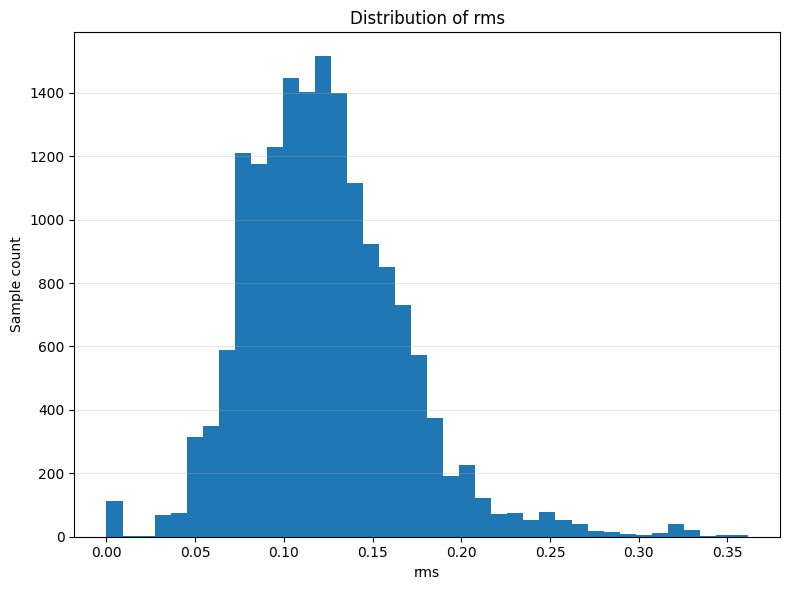

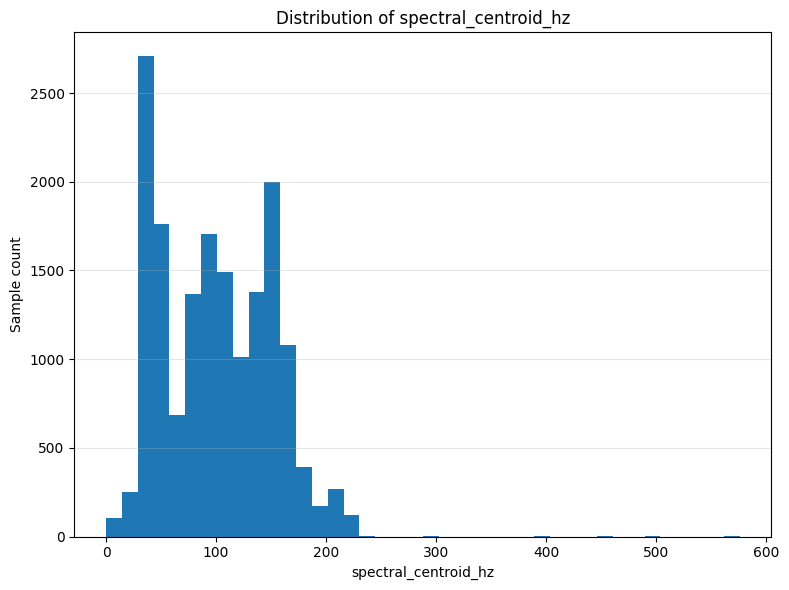

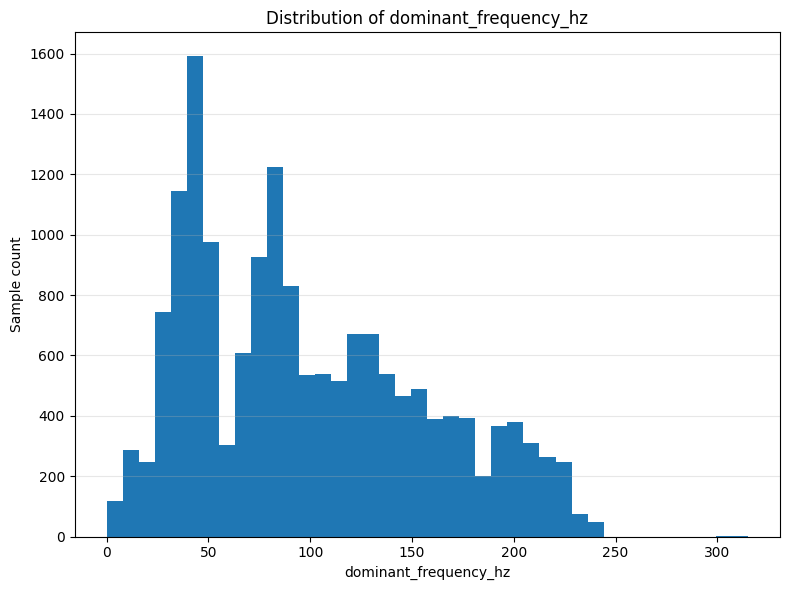

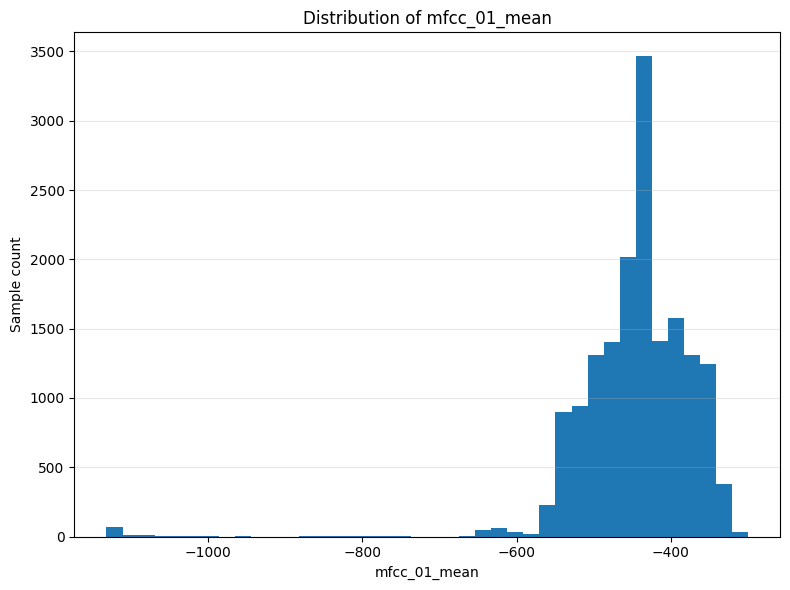

In [24]:
# At minimum, plot a few representative feature distributions:

selected_feature_plots = [
    "rms",
    "spectral_centroid_hz",
    "dominant_frequency_hz",
    "mfcc_01_mean",
]

for feature_name in (
    selected_feature_plots
):

    fig, ax = plt.subplots(
        figsize=(8, 6)
    )

    ax.hist(
        baseline_features[
            feature_name
        ],
        bins=40,
    )

    ax.set_title(
        f"Distribution of {feature_name}"
    )

    ax.set_xlabel(
        feature_name
    )

    ax.set_ylabel(
        "Sample count"
    )

    ax.grid(
        True,
        axis="y",
        alpha=0.3,
    )

    fig.tight_layout()

    output_path = (
        BASELINE_FEATURE_FIGURE_DIR
        / f"{feature_name}_distribution.png"
    )

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    # Do not do feature selection yet.

In [25]:
# Step 9 — Fingerprint FEAT-001
# Calculate SHA-256

import hashlib

sha256 = hashlib.sha256()

with open(
    BASELINE_FEATURE_PATH,
    "rb",
) as file:

    for block in iter(
        lambda: file.read(
            1024 * 1024
        ),
        b"",
    ):
        sha256.update(block)

FEATURE_SHA256 = (
    sha256.hexdigest()
)

print(
    "FEAT-001 SHA-256:"
)

print(
    FEATURE_SHA256
)

FEAT-001 SHA-256:
5d098ad00f279a91f92029fbfb57f6e929c1f699cf39ce90eab7ee0f70958620


In [26]:
# Generate the GitHub record:
feature_record = {

    "artifact": {
        "name":
            "baseline_features_v001.parquet",

        "feature_version":
            "FEAT-001",

        "status":
            "frozen",

        "storage":
            "Google Drive",

        "logical_path":
            (
                "data/cached_features/"
                "FEAT-001/"
                "baseline_features_v001.parquet"
            ),

        "sha256":
            FEATURE_SHA256,
    },

    "population": {
        "sample_count":
            int(
                len(baseline_features)
            ),

        "predictor_count":
            int(
                len(FEATURE_COLUMNS)
            ),
    },

    "upstream": {
        "preprocessing":
            "PREP-001",

        "split":
            "SPLIT-001",

        "sample_manifest":
            "SAMPLE-MANIFEST-001",

        "order_analysis":
            "ORDER-001",
    },

    "rpm_baseline_policy": {
        "target":
            "rpm_mean",

        "eligible_filter":
            "model_eligible_rpm_v001 == True",

        "ground_truth_rpm_order_features_used":
            False,
    },
}


FEATURE_RECORD_PATH = (
    REPO_DIR
    / "data"
    / "baseline_features_v001_record.yaml"
)

with open(
    FEATURE_RECORD_PATH,
    "w",
    encoding="utf-8",
) as file:

    yaml.safe_dump(
        feature_record,
        file,
        sort_keys=False,
    )

print(
    f"Saved:\n"
    f"{FEATURE_RECORD_PATH}"
)

Saved:
/content/engine-nvh-deep-learning/data/baseline_features_v001_record.yaml


In [27]:
# Closing out today's sesison cleanly

# 1. Verify the persistent FEAT-001 file still exists
# and matches its record

# ============================================================
# CLOSEOUT 1 — VERIFY PERSISTENT FEAT-001
# ============================================================

import hashlib
import yaml
import pandas as pd

BASELINE_FEATURE_PATH = (
    PROJECT_DRIVE
    / "data"
    / "cached_features"
    / "FEAT-001"
    / "baseline_features_v001.parquet"
)

FEATURE_RECORD_PATH = (
    REPO_DIR
    / "data"
    / "baseline_features_v001_record.yaml"
)

assert BASELINE_FEATURE_PATH.exists(), (
    f"Missing FEAT-001 file:\n{BASELINE_FEATURE_PATH}"
)

assert FEATURE_RECORD_PATH.exists(), (
    f"Missing feature record:\n{FEATURE_RECORD_PATH}"
)

feature_check = pd.read_parquet(
    BASELINE_FEATURE_PATH
)

assert feature_check["sample_id"].is_unique

print(
    f"FEAT-001 rows: "
    f"{len(feature_check):,}"
)

# Recalculate SHA-256
sha256 = hashlib.sha256()

with open(
    BASELINE_FEATURE_PATH,
    "rb",
) as file:

    for block in iter(
        lambda: file.read(1024 * 1024),
        b"",
    ):
        sha256.update(block)

current_sha256 = sha256.hexdigest()

with open(
    FEATURE_RECORD_PATH,
    "r",
    encoding="utf-8",
) as file:

    feature_record_check = yaml.safe_load(file)

recorded_sha256 = (
    feature_record_check[
        "artifact"
    ]["sha256"]
)

assert current_sha256 == recorded_sha256, (
    "FEAT-001 checksum does not match "
    "baseline_features_v001_record.yaml."
)

print(
    "PASS: FEAT-001 exists in Drive "
    "and its fingerprint matches."
)

FEAT-001 rows: 16,503
PASS: FEAT-001 exists in Drive and its fingerprint matches.


In [28]:
# 2. Verify all Notebook 06 GitHub-side artifacts exist
# You want:
# All required outputs present: True

# ============================================================
# CLOSEOUT 2 — NOTEBOOK 06 ARTIFACT AUDIT
# ============================================================

expected_outputs = [
    "configs/features_v001.yaml",
    "src/audio_features.py",
    "data/baseline_features_v001_record.yaml",
    "results/tables/feature_summary_v001.csv",
    "results/figures/baseline_features",
    "requirements.txt",
]

print("Notebook 06 artifact audit")
print("=" * 70)

all_present = True

for relative_path in expected_outputs:

    full_path = (
        REPO_DIR
        / relative_path
    )

    if full_path.is_file():

        print(
            f"PASS FILE : {relative_path}"
        )

    elif full_path.is_dir():

        files = [
            path
            for path in full_path.rglob("*")
            if path.is_file()
        ]

        print(
            f"PASS DIR  : {relative_path} "
            f"({len(files)} files)"
        )

        if len(files) == 0:
            all_present = False

    else:

        print(
            f"MISSING   : {relative_path}"
        )

        all_present = False


print()
print(
    "All required outputs present:",
    all_present,
)

Notebook 06 artifact audit
PASS FILE : configs/features_v001.yaml
PASS FILE : src/audio_features.py
PASS FILE : data/baseline_features_v001_record.yaml
PASS FILE : results/tables/feature_summary_v001.csv
PASS DIR  : results/figures/baseline_features (4 files)
PASS FILE : requirements.txt

All required outputs present: True


In [29]:
# 3. Verify the reusable feature module imports from disk
# This confirms audio_features.py isn't merely something that worked in
# today's notebook RAM.

# ============================================================
# CLOSEOUT 3 — VERIFY SAVED FEATURE MODULE
# ============================================================

import sys
import importlib

if str(REPO_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(REPO_DIR),
    )

import src.audio_features

importlib.reload(
    src.audio_features
)

from src.audio_features import (
    extract_baseline_features
)

print(
    "PASS: src.audio_features "
    "imports from the repository."
)

PASS: src.audio_features imports from the repository.


In [30]:
# 5. Stage the locally generated Notebook 06 artifacts
# You saved this notebook directly to GitHub from Colab, so
# you dont need to separatelt add/commit the notebook.
# but that means GitHub may become one commit ahead of your local /content clone
# After saving the notebook to GitHub, stage the files generated
# inside the local clone

# ============================================================
# CLOSEOUT 4 — STAGE NOTEBOOK 06 ARTIFACTS
# ============================================================

import subprocess

paths_to_add = [
    "configs/features_v001.yaml",
    "src/audio_features.py",
    "data/baseline_features_v001_record.yaml",
    "results/tables/feature_summary_v001.csv",
    "results/figures/baseline_features",
    "requirements.txt",
]

existing_paths = [
    path
    for path in paths_to_add
    if (REPO_DIR / path).exists()
]

print("Staging:")

for path in existing_paths:
    print(" +", path)

add_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "add",
        *existing_paths,
    ],
    capture_output=True,
    text=True,
)

print(add_result.stdout)

if add_result.stderr:
    print(add_result.stderr)

if add_result.returncode != 0:
    raise RuntimeError(
        "git add failed."
    )

Staging:
 + configs/features_v001.yaml
 + src/audio_features.py
 + data/baseline_features_v001_record.yaml
 + results/tables/feature_summary_v001.csv
 + results/figures/baseline_features
 + requirements.txt



In [31]:
# inspect
status_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "status",
        "--short",
    ],
    capture_output=True,
    text=True,
    check=True,
)

print(status_result.stdout)

A  configs/features_v001.yaml
A  data/baseline_features_v001_record.yaml
A  results/figures/baseline_features/dominant_frequency_hz_distribution.png
A  results/figures/baseline_features/mfcc_01_mean_distribution.png
A  results/figures/baseline_features/rms_distribution.png
A  results/figures/baseline_features/spectral_centroid_hz_distribution.png
A  results/tables/feature_summary_v001.csv
A  src/audio_features.py
?? src/__pycache__/



In [32]:
# 6. Commit FEAT-001 artifacts

# ============================================================
# CLOSEOUT 5 — COMMIT FEAT-001
# ============================================================

commit_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "commit",
        "-m",
        "Freeze FEAT-001 baseline features",
    ],
    capture_output=True,
    text=True,
)

print(commit_result.stdout)

if commit_result.stderr:
    print(commit_result.stderr)

if (
    commit_result.returncode != 0
    and
    "nothing to commit"
    not in (
        commit_result.stdout
        + commit_result.stderr
    ).lower()
):
    raise RuntimeError(
        "Git commit failed."
    )

[main ef2e109] Freeze FEAT-001 baseline features
 8 files changed, 434 insertions(+)
 create mode 100644 configs/features_v001.yaml
 create mode 100644 data/baseline_features_v001_record.yaml
 create mode 100644 results/figures/baseline_features/dominant_frequency_hz_distribution.png
 create mode 100644 results/figures/baseline_features/mfcc_01_mean_distribution.png
 create mode 100644 results/figures/baseline_features/rms_distribution.png
 create mode 100644 results/figures/baseline_features/spectral_centroid_hz_distribution.png
 create mode 100644 results/tables/feature_summary_v001.csv
 create mode 100644 src/audio_features.py



In [33]:
# 7. Bring in the direct notebook-save commit from GitHub

# Determine the current branch
current_branch = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "branch",
        "--show-current",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()

print(
    f"Current branch: {current_branch}"
)

Current branch: main


In [34]:
#..then
# ============================================================
# CLOSEOUT 6 — RECONCILE WITH REMOTE NOTEBOOK SAVE
# ============================================================

pull_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "pull",
        "--rebase",
        "origin",
        current_branch,
    ],
    capture_output=True,
    text=True,
)

print(pull_result.stdout)

if pull_result.stderr:
    print(pull_result.stderr)

if pull_result.returncode != 0:
    raise RuntimeError(
        "git pull --rebase failed. "
        "Resolve before ending the session."
    )


From https://github.com/vaibhavjiyer87/engine-nvh-deep-learning
 * branch            main       -> FETCH_HEAD
   4ff9042..f64be15  main       -> origin/main
Rebasing (1/1)

Successfully rebased and updated refs/heads/main.



In [35]:
# 8. Push everything
# ============================================================
# CLOSEOUT 7 — PUSH FEAT-001 ARTIFACTS
# ============================================================

push_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "push",
        "origin",
        current_branch,
    ],
    capture_output=True,
    text=True,
)

print(push_result.stdout)

if push_result.stderr:
    print(push_result.stderr)

if push_result.returncode != 0:
    raise RuntimeError(
        "Git push failed."
    )

print(
    "PASS: FEAT-001 GitHub artifacts pushed."
)


To https://github.com/vaibhavjiyer87/engine-nvh-deep-learning.git
   f64be15..74ba579  main -> main

PASS: FEAT-001 GitHub artifacts pushed.


In [36]:
# 9. Final synchronization check
# This is the 'safe-to-disconnect' test

# ============================================================
# CLOSEOUT 8 — FINAL GITHUB SYNCHRONIZATION CHECK
# ============================================================

subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "fetch",
        "origin",
    ],
    check=True,
)

local_head = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "rev-parse",
        "HEAD",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()

remote_head = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "rev-parse",
        f"origin/{current_branch}",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()

print("Local :", local_head)
print("Remote:", remote_head)

assert local_head == remote_head

final_status = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "status",
        "--porcelain",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()

if final_status:

    print(
        "\nWARNING: Uncommitted files remain:"
    )

    print(final_status)

else:

    print(
        "\nPASS: Working tree is clean."
    )

print(
    "\nPASS: FEAT-001 session closeout complete."
)

Local : 74ba579fa8b2bfa04b18e4d906576933c2154855
Remote: 74ba579fa8b2bfa04b18e4d906576933c2154855

?? src/__pycache__/

PASS: FEAT-001 session closeout complete.


No real project artifact is missing. src/__pycache__/ is just Python’s automatically generated bytecode cache from importing src.data_loader / src.audio_features.

We should not commit it. The permanent fix is to ignore Python cache files in Git

In [37]:
# Add Python cache rules to .gitignore
# ============================================================
# PERMANENTLY IGNORE PYTHON CACHE FILES
# ============================================================

GITIGNORE_PATH = REPO_DIR / ".gitignore"

existing = ""

if GITIGNORE_PATH.exists():
    existing = GITIGNORE_PATH.read_text(
        encoding="utf-8"
    )

rules_to_add = [
    "__pycache__/",
    "*.py[cod]",
]

lines = set(
    line.strip()
    for line in existing.splitlines()
)

new_rules = [
    rule
    for rule in rules_to_add
    if rule not in lines
]

if new_rules:

    with open(
        GITIGNORE_PATH,
        "a",
        encoding="utf-8",
    ) as file:

        if existing and not existing.endswith("\n"):
            file.write("\n")

        file.write(
            "\n# Python cache files\n"
        )

        for rule in new_rules:
            file.write(
                rule + "\n"
            )

    print(
        "Added Python cache rules "
        "to .gitignore."
    )

else:

    print(
        "Python cache rules already "
        "exist in .gitignore."
    )

Added Python cache rules to .gitignore.


In [38]:
# make sure these common notebook/runtime files are ignored
additional_rules = [
    ".ipynb_checkpoints/",
    ".DS_Store",
]

existing = GITIGNORE_PATH.read_text(
    encoding="utf-8"
)

lines = set(
    line.strip()
    for line in existing.splitlines()
)

with open(
    GITIGNORE_PATH,
    "a",
    encoding="utf-8",
) as file:

    for rule in additional_rules:
        if rule not in lines:
            file.write(
                rule + "\n"
            )

print("Notebook/system ignore rules checked.")

Notebook/system ignore rules checked.


In [39]:
# Remove the current cache directory
# This is safe; Python will recreate it whenever needed.

import shutil

PY_CACHE_DIR = (
    REPO_DIR
    / "src"
    / "__pycache__"
)

if PY_CACHE_DIR.exists():

    shutil.rmtree(
        PY_CACHE_DIR
    )

    print(
        "Removed src/__pycache__/"
    )

else:

    print(
        "No src/__pycache__/ "
        "directory currently exists."
    )

Removed src/__pycache__/


In [40]:
# 3. Commit the .gitignore change
# Because .gitignore is a real repository configuration change, commit it:

import subprocess

subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "add",
        ".gitignore",
    ],
    check=True,
)

commit_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "commit",
        "-m",
        "Ignore Python cache files",
    ],
    capture_output=True,
    text=True,
)

print(commit_result.stdout)
print(commit_result.stderr)

[main 6f5592b] Ignore Python cache files
 1 file changed, 6 insertions(+)




In [41]:
#.. then PUSH
current_branch = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "branch",
        "--show-current",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()

subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "push",
        "origin",
        current_branch,
    ],
    check=True,
)

print(
    "PASS: .gitignore update pushed."
)

PASS: .gitignore update pushed.


In [42]:
# 4. Re-run the final clean-tree check
final_status = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "status",
        "--porcelain",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()

if final_status:

    print(
        "WARNING: Uncommitted files remain:"
    )
    print(final_status)

else:

    print(
        "PASS: Working tree is clean."
    )

PASS: Working tree is clean.
